# Lab 01: Digital Image Fundamentals

**Lab:** Computer Vision Lab  

## Learning Objectives

By the end of this lab, you should be able to:

1. Explain a digital image mathematically.
2. Understand pixels, coordinates, dimensions, and channels.
3. Represent grayscale, binary, and RGB images with NumPy.
4. Explain uint8, bit depth, intensity levels, and storage.
5. Distinguish **sampling** from **quantization**.
6. Calculate raw image storage.
7. Compute basic image statistics.
8. Load and inspect a real image with OpenCV.
10. Understand OpenCV BGR versus RGB.

## 1. What Is Computer Vision?

A camera observes a physical scene. A computer works with numerical data.

The fundamental pipeline is:

$$
\boxed{\text{Real Scene}\rightarrow\text{Sampling}\rightarrow\text{Pixels}\rightarrow\text{Quantization}\rightarrow\text{Numerical Array}\rightarrow\text{Computer Vision}}
$$

Later labs will operate on these arrays using transformations, point operations, filtering, feature extraction, and learning-based methods.

First understand image representation; then understand image processing.

## 2. Mathematical Representation of an Image

A grayscale image can be represented as a 2-D function:

$$I(m,n)$$

where $m$ is the row, $n$ is the column, and $I(m,n)$ is the intensity.

For an 8-bit grayscale image:

$$I(m,n)\in[0,255]$$

- 0 → black
- 255 → white
- values between them → shades of gray

For an RGB image:

$$I(m,n)=[R,G,B]$$

## 3. Pixel and Coordinates

A **pixel** is one spatial sample of an image.

Example:

$$
I=
\begin{bmatrix}
10&20&30\\
40&50&60\\
70&80&90
\end{bmatrix}
$$

Then:

$$I[1,2]=60$$

because Python/NumPy uses zero-based indexing.

### Important distinction

- **Pixel:** one spatial image sample.
- **Resolution:** number of spatial pixels.
- **Intensity/channel value:** numerical value stored at a pixel.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

image = np.array([
    [10, 20, 30],
    [40, 50, 60],
    [70, 80, 90]
], dtype=np.uint8)

print(image)
print("Shape:", image.shape)
print("Pixel [1,2]:", image[1, 2])

[[10 20 30]
 [40 50 60]
 [70 80 90]]
Shape: (3, 3)
Pixel [1,2]: 60


### Observation

The shape is `(3,3)`, so:

$$3\times3=9$$ spatial pixels.

The computer processes the matrix numerically rather than seeing the image as a human does.

## 4. Grayscale and Binary Images

A grayscale image contains one intensity value per pixel:

$$0\le I(m,n)\le255$$

Its NumPy shape is:

$$\boxed{(H,W)}$$

A binary image has two logical states, commonly represented for display as 0 and 255.

For one bit:

$$L=2^1=2$$

Although one bit is conceptually sufficient, binary images are often stored in `uint8` arrays with values 0 and 255.

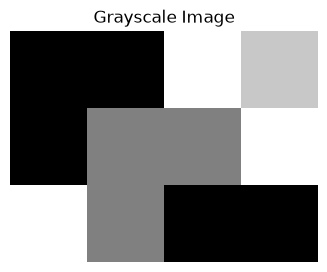

Shape: (3, 4)
Pixels: 12


In [4]:
gray = np.array([
    [0, 0, 255, 200],
    [0, 128, 128, 255],
    [255, 128, 0, 0]
], dtype=np.uint8)

plt.figure(figsize=(5, 3))
plt.imshow(gray, cmap="gray", vmin=0, vmax=255)
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

print("Shape:", gray.shape)
print("Pixels:", gray.size)

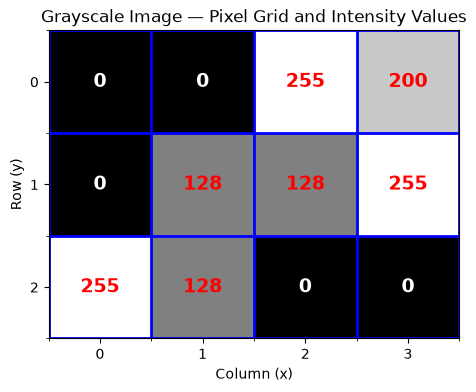

Shape: (3, 4)
Pixels: 12


In [5]:
# Create figure
fig, ax = plt.subplots(figsize=(6, 4))
# Display image
ax.imshow(gray, cmap="gray", vmin=0, vmax=255)
# Add pixel values
for i in range(gray.shape[0]):
    for j in range(gray.shape[1]):
        ax.text(
            j, i,
            str(gray[i, j]),
            ha="center",
            va="center",
            color="red" if gray[i, j] > 127 else "white",
            fontsize=14,
            fontweight="bold"
        )
# Create grid lines
ax.set_xticks(np.arange(-0.5, gray.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, gray.shape[0], 1), minor=True)
ax.grid(
    which="minor",
    color="blue",
    linestyle="-",
    linewidth=2
)
# Show row/column coordinates
ax.set_xticks(np.arange(gray.shape[1]))
ax.set_yticks(np.arange(gray.shape[0]))
ax.set_xlabel("Column (x)")
ax.set_ylabel("Row (y)")
ax.set_title("Grayscale Image — Pixel Grid and Intensity Values")
plt.show()
print("Shape:", gray.shape)
print("Pixels:", gray.size)

In [6]:
# Convert NumPy array to PIL Image
from PIL import Image
img = Image.fromarray(gray)
# Save image
img.save("grayscale_image.png")
img.save("grayscale_image.jpeg")

## 5. RGB Color Images

An RGB pixel contains three channel values:

$$I(m,n)=[R,G,B]$$

Therefore an RGB image normally has shape:

$$\boxed{(H,W,3)}$$

For `(720,1280,3)`:

- height = 720
- width = 1280
- channels = 3
- spatial pixels = $720\times1280=921,600$
- channel values = $720\times1280\times3=2,764,800$

(300, 300, 3)


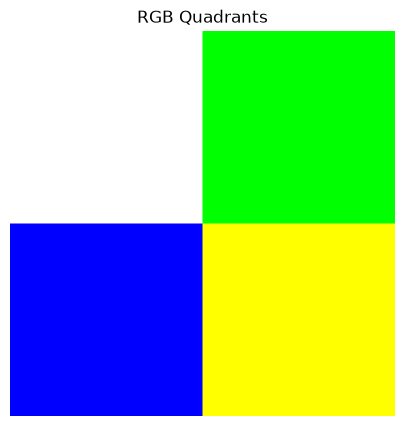

In [9]:
rgb = np.zeros((300, 300, 3), dtype=np.uint8)
print(rgb.shape)
rgb[:150, :150] = [255, 255, 255]      # red
rgb[:150, 150:] = [0, 255, 0]      # green
rgb[150:, :150] = [0, 0, 255]      # blue
rgb[150:, 150:] = [255, 255, 0]    # yellow

plt.figure(figsize=(5, 5))
plt.imshow(rgb)
plt.title("RGB Quadrants")
plt.axis("off")
plt.show()

Each 8-bit channel has:

$$2^8=256$$

possible values. Therefore an 8-bit RGB image has:

$$256^3=16,777,216$$

possible RGB combinations.

**Important:** this is the number of possible color combinations, not the number of pixels.

| Color | RGB               | Grayscale |
| ----- | ----------------- | --------- |
| Black | `(0, 0, 0)`       | `0`       |
| Gray  | `(128, 128, 128)` | `128`     |
| White | `(255, 255, 255)` | `255`     |


## 6. uint8 and Bit Depth

`uint8` means **unsigned 8-bit integer**.

It provides:

$$0\le x\le255$$

because there are:

$$2^8=256$$

possible values.

For $B$ bits:

$$\boxed{L=2^B}$$

| Bits | Levels | Range |
|---:|---:|---:|
| 1 | 2 | 0–1 |
| 2 | 4 | 0–3 |
| 4 | 16 | 0–15 |
| 8 | 256 | 0–255 |
| 16 | 65,536 | 0–65,535 |

**Spatial resolution** describes how many pixels sample the scene(H *W).  
**Gray-level resolution** describes how many intensity levels each pixel can represent(How precisely can each pixel represent brightness?
1-bit:
0 ───── 1
black   white

8-bit:
0 ───────────────────────── 255
black                    white
).

In [28]:
for bits in [1, 2, 4, 8, 16]:
    levels = 2 ** bits
    print(f"{bits:2d} bits -> {levels:6d} levels -> 0 to {levels-1}")

 1 bits ->      2 levels -> 0 to 1
 2 bits ->      4 levels -> 0 to 3
 4 bits ->     16 levels -> 0 to 15
 8 bits ->    256 levels -> 0 to 255
16 bits ->  65536 levels -> 0 to 65535


In [34]:
# RGB Memory Calculation
H = 1080
W = 1920
channels = 3
bits_per_channel = 8

total_bits = H * W * channels * bits_per_channel
total_bytes = total_bits / 8
total_mib = total_bytes / (1024 ** 2)

print("Resolution:", f"{W} x {H}")
print("Total pixels:", H * W)
print("Bits:", total_bits)
print("Bytes:", int(total_bytes))
print("MiB:", round(total_mib, 2))

Resolution: 1920 x 1080
Total pixels: 2073600
Bits: 49766400
Bytes: 6220800
MiB: 5.93


In [33]:
def raw_storage(H, W, channels, bits_per_channel):
    bits = H * W * channels * bits_per_channel
    bytes_ = bits / 8
    mib = bytes_ / (1024 ** 2)
    return bits, bytes_, mib
examples = [
    (640, 480, 1, 8, "640×480 grayscale"),
    (640, 480, 3, 8, "640×480 RGB"),
    (1920, 1080, 3, 8, "1920×1080 RGB"),
    (3840, 2160, 3, 8, "3840×2160 RGB"),
]
for H, W, C, B, name in examples:
    bits, bytes_, mib = raw_storage(H, W, C, B)
    print(f"{name}: {int(bytes_):,} bytes = {mib:.2f} MiB")

640×480 grayscale: 307,200 bytes = 0.29 MiB
640×480 RGB: 921,600 bytes = 0.88 MiB
1920×1080 RGB: 6,220,800 bytes = 5.93 MiB
3840×2160 RGB: 24,883,200 bytes = 23.73 MiB


### Worked Example

For 1920×1080 RGB, 8-bit/channel:

$$1920\times1080\times3=6,220,800\text{ bytes}$$

and:

$$\frac{6,220,800}{1024^2}\approx5.93\text{ MiB}$$

JPEG/PNG file size can be different because those formats use compression.

## 7. Sampling

A real image can be modeled as a continuous function:

$$f(x,y)$$

Sampling converts continuous spatial coordinates into discrete locations:

$$\boxed{I[m,n]=f(m\Delta x,n\Delta y)}$$

**Sampling answers:** *At which spatial locations do we measure the scene?*

Reducing spatial sampling generally reduces fine spatial detail.

In [10]:
# Synthetic high-resolution gradient
high = np.tile(np.linspace(0, 255, 1024, dtype=np.uint8), (768, 1))
print(high)
# Downsample by selecting regularly spaced samples
for factor in [1, 2, 4, 8, 16]:
    sampled = high[::factor, ::factor] #shape h/factor*w/factor
    print(f"Sampling factor {factor}: shape = {sampled.shape}")

[[  0   0   0 ... 254 254 255]
 [  0   0   0 ... 254 254 255]
 [  0   0   0 ... 254 254 255]
 ...
 [  0   0   0 ... 254 254 255]
 [  0   0   0 ... 254 254 255]
 [  0   0   0 ... 254 254 255]]
Sampling factor 1: shape = (768, 1024)
Sampling factor 2: shape = (384, 512)
Sampling factor 4: shape = (192, 256)
Sampling factor 8: shape = (96, 128)
Sampling factor 16: shape = (48, 64)


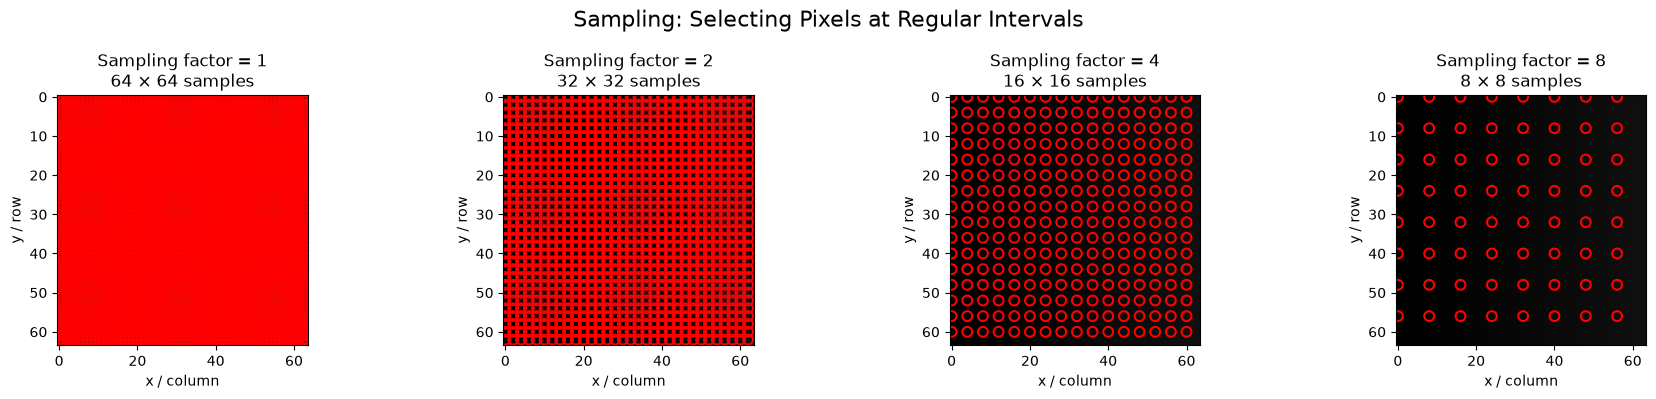

In [12]:
# High-resolution gradient
high = np.tile(
    np.linspace(0, 255, 1024, dtype=np.uint8),
    (768, 1)
)
# Use a smaller section so sampling points are visible
region = high[:64, :64]
factors = [1, 2, 4, 8]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, factor in zip(axes, factors):
    # Original region
    ax.imshow(
        region,
        cmap="gray",
        vmin=0,
        vmax=255,
        interpolation="nearest"
    )
    # Sampling coordinates
    y = np.arange(0, region.shape[0], factor)
    x = np.arange(0, region.shape[1], factor)
    # Show sampling locations
    X, Y = np.meshgrid(x, y)
    ax.scatter(
        X,
        Y,
        facecolors="none",
        edgecolors="red",
        s=50,
        linewidths=1.5
    )
    ax.set_title(
        f"Sampling factor = {factor}\n"
        f"{len(y)} × {len(x)} samples"
    )
    ax.set_xlabel("x / column")
    ax.set_ylabel("y / row")
plt.suptitle(
    "Sampling: Selecting Pixels at Regular Intervals",
    fontsize=16
)
plt.tight_layout()
plt.show()

In [31]:
# Sampling changes how densely the continuous/spatial scene is represented by discrete pixel locations.

Original shape: (224, 225)


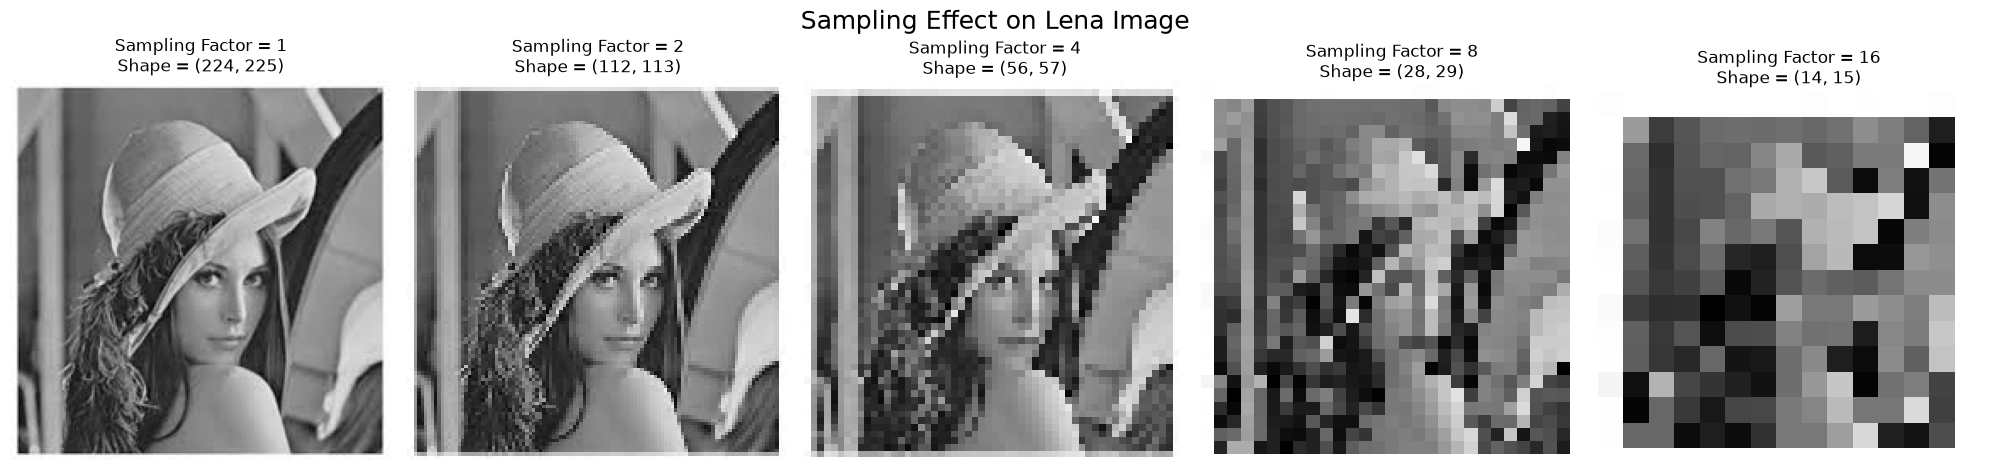

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load Lena image
lena = cv2.imread("images.jpg", cv2.IMREAD_GRAYSCALE)

if lena is None:
    raise FileNotFoundError("Could not find lena.png")
print("Original shape:", lena.shape)
# Sampling factors
factors = [1, 2, 4, 8, 16]
# Create visualization
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, factor in zip(axes, factors):

    # Sample every factor-th row and column
    sampled = lena[::factor, ::factor]

    # Display
    ax.imshow(sampled, cmap="gray")
    ax.set_title(
        f"Sampling Factor = {factor}\n"
        f"Shape = {sampled.shape}"
    )
    ax.axis("off")
plt.suptitle(
    "Sampling Effect on Lena Image",
    fontsize=18
)
plt.tight_layout()
plt.show()

## 8. Quantization

Quantization discretizes **intensity values**.

Sampling changes WHERE we have pixels:

Quantization changes WHAT VALUE each pixel can have:

Sampling and quantization are different:

$$\boxed{\text{Sampling} = \text{spatial discretization}}$$

$$\boxed{\text{Quantization} = \text{intensity discretization}}$$

So:

- sampling asks **where** we measure;
- quantization asks **which intensity levels** are allowed.

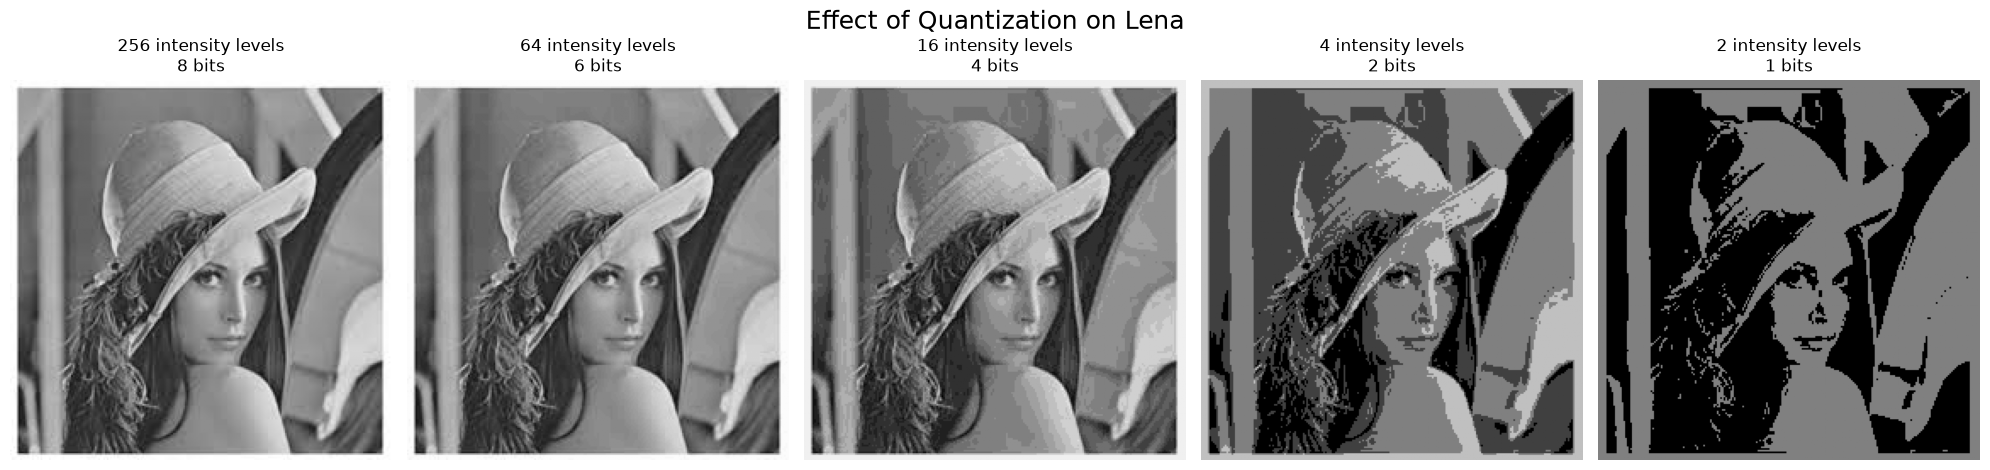

In [32]:
# Load Lena as grayscale
lena = cv2.imread("images.jpg", cv2.IMREAD_GRAYSCALE)

# Quantization function
def quantize_image(image, levels):
    step = 256 / levels

    quantized = np.floor(image / step) * step

    return quantized.astype(np.uint8)

# Different quantization levels
levels_list = [256, 64, 16, 4, 2]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, levels in zip(axes, levels_list):

    quantized = quantize_image(lena, levels)

    ax.imshow(quantized, cmap="gray", vmin=0, vmax=255)

    ax.set_title(
        f"{levels} intensity levels\n"
        f"{int(np.log2(levels))} bits"
    )

    ax.axis("off")

plt.suptitle(
    "Effect of Quantization on Lena",
    fontsize=18
)

plt.tight_layout()
plt.show()

## 09. Load a Real Image with OpenCV

OpenCV commonly loads color images in **BGR** order:

$$[B,G,R]$$

Matplotlib normally expects RGB:

$$[R,G,B]$$

Therefore, for display:

```python
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
```

This distinction is a common source of incorrect colors.

In [35]:
import cv2
import os

image_path = "image.jpg"

if os.path.exists(image_path):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise ValueError("OpenCV could not decode the image.")
    print("Shape:", img_bgr.shape)
    print("dtype:", img_bgr.dtype)
    cv2.imshow("BGR Image", img_bgr)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
else:
    print("Place image.jpg beside the notebook to run the real-image sections.")

Shape: (512, 512, 3)
dtype: uint8


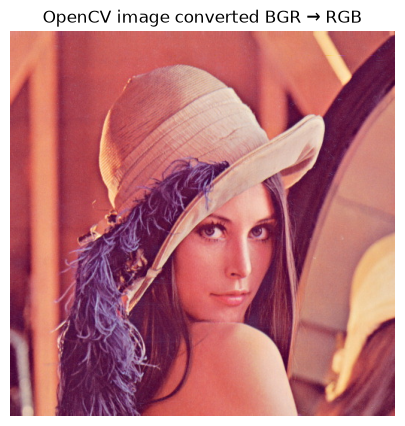

In [36]:
if 'img_bgr' in globals():
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 5))
    plt.imshow(img_rgb)
    plt.title("OpenCV image converted BGR → RGB")
    plt.axis("off")
    plt.show()

## 10. RGB → Grayscale

A common luminance-weighted conversion is:

$$\boxed{Y=0.299R+0.587G+0.114B}$$

For $R=100,G=150,B=200$:

$$Y\approx141$$

OpenCV can perform this conversion directly.

Color shape: (512, 512, 3)
Grayscale shape: (512, 512)


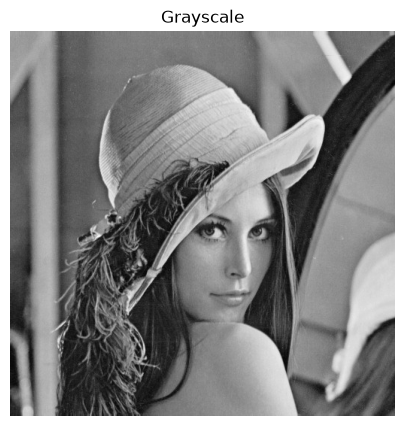

In [37]:
if 'img_bgr' in globals():
    gray_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    print("Color shape:", img_bgr.shape)
    print("Grayscale shape:", gray_img.shape)

    plt.figure(figsize=(8, 5))
    plt.imshow(gray_img, cmap="gray")
    plt.title("Grayscale")
    plt.axis("off")
    plt.show()

## 11. Basic Image Statistics

For values $x_1,\dots,x_N$:

### Mean

$$\mu=\frac{1}{N}\sum_{i=1}^{N}x_i$$

### Variance

$$\sigma^2=\frac{1}{N}\sum_{i=1}^{N}(x_i-\mu)^2$$

### Standard deviation

$$\sigma=\sqrt{\sigma^2}$$


Interpretation matters: not merely print the numbers; explain what they tell you about intensity distribution.

In [38]:
if 'gray_img' in globals():
    print(f"Mean:               {np.mean(gray_img):.2f}")
    print(f"Variance:           {np.var(gray_img):.2f}")
    print(f"Standard deviation: {np.std(gray_img):.2f}")
    print(f"Minimum:            {np.min(gray_img)}")
    print(f"Maximum:            {np.max(gray_img)}")

Mean:               124.20
Variance:           2294.37
Standard deviation: 47.90
Minimum:            20
Maximum:            245


## 12. Thresholding

Thresholding converts grayscale values into two classes.

For threshold $T$:

$$
B[r,c]=
\begin{cases}
255,&I[r,c]\ge T\\
0,&I[r,c]<T
\end{cases}
$$

Try different values such as:

$$T=64,100,128,180,220$$

Observe how the binary result changes.

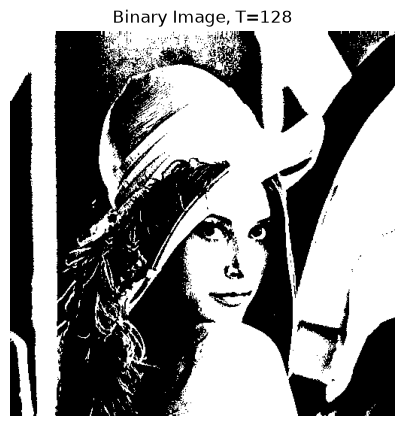

In [57]:
if 'gray_img' in globals():
    T = 128
    binary_img = np.where(gray_img >= T, 255, 0).astype(np.uint8)

    plt.figure(figsize=(8, 5))
    plt.imshow(binary_img, cmap="gray", vmin=0, vmax=255)
    plt.title(f"Binary Image, T={T}")
    plt.axis("off")
    plt.show()

## 13. Pixel Manipulation

In [59]:
if 'img_bgr' in globals():

    modified_img = img_rgb.copy()

    #print("Original pixel:", img_rgb[100, 100])

    #modified_img[100, 100] = 0
    modified_img[100:200, 100:300] = [255,0,0]
    print("Modified pixel:", modified_img[100, 100])

Modified pixel: [255   0   0]


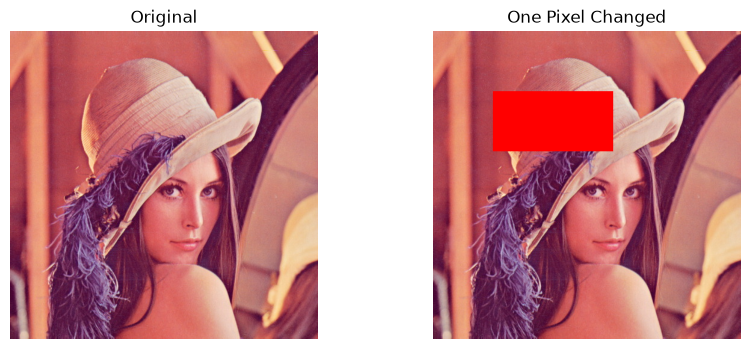

In [60]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(modified_img, cmap="gray")
plt.title("One Pixel Changed")
plt.axis("off")

plt.show()

## Image Slicing and ROI

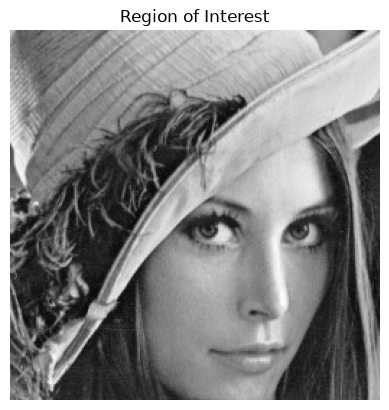

In [61]:
if 'gray_img' in globals():
    h, w = gray_img.shape
    roi = gray_img[
        h//4 : 3*h//4,
        w//4 : 3*w//4
    ]
    plt.imshow(roi, cmap="gray")
    plt.title("Region of Interest")
    plt.axis("off")
    plt.show()

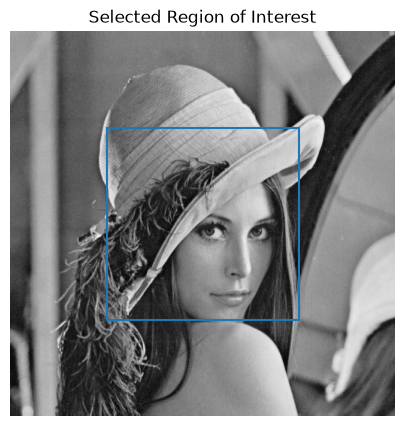

In [65]:
if 'gray_img' in globals():
    h, w = gray_img.shape
    y1, y2 = h//4, 3*h//4
    x1, x2 = w//4, 3*w//4
    roi = gray_img[y1:y2, x1:x2]
    plt.figure(figsize=(8, 5))
    plt.imshow(gray_img, cmap="gray")
    plt.plot(
        [x1, x2, x2, x1, x1],
        [y1, y1, y2, y2, y1]
    )
    plt.title("Selected Region of Interest")
    plt.axis("off")
    plt.show()